# MTH9877 — Assignment 3: Part E(iii) — Neural Survival Models

**Standalone notebook.**

---
## E(iii) — Longitudinal DeepHit with Transformer Encoder

A shared Transformer encoder reads the full monthly covariate history `[x₁, …, xₜ]`
of each mortgage, then two cause-specific output heads produce discrete monthly hazard
rates over a 120-month time grid.

**Key advantages over Cox / DeepCox:**
- No proportional-hazards assumption — nonlinear, time-varying risk
- Competing risks modelled end-to-end via a shared representation
- Attention weights are interpretable: identify *which months* drive the prediction
- Gradient sensitivity replicates Sadhwani (2021) feature-importance analysis

**Architecture:**
```
Input  (B, T_max=120, D=13)
  → Linear projection  →  d_model=64
  → Sinusoidal positional encoding  (on loan_age)
  → Transformer Encoder  ×2 layers, 4 heads, causal mask
  → Last valid hidden state  h ∈ R^64
  → Prepayment head  (FC 64→128→T_max, Sigmoid)   λ₁(t|x)
  → Default head     (FC 64→128→T_max, Sigmoid)   λ₂(t|x)
  → CIF₁(t), CIF₂(t)  via competing-risk chain product
```

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import math
import warnings
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index

warnings.filterwarnings("ignore")

BASE          = Path("/Users/yueqilin/Desktop/MTH9877 IR/IR&C Assignment3")
OUT_DIR       = BASE / "processed"
SURVIVAL_PATH = OUT_DIR / "survival_loans.parquet"
PANEL_PATH    = OUT_DIR / "panel_monthly.parquet"
MACRO_PATH    = OUT_DIR / "macro_monthly.parquet"

# ── Partner A-D paths ─────────────────────────────────────────────────────────
ATOD_BASE  = BASE / "AtoD"
ATOD_CANON = ATOD_BASE / "results_cd/canonical_split.parquet"

# Part D DeepCox AUC benchmarks (partner's full-training-set model on canonical test)
PARTD_AUC = {12: 0.6837, 24: 0.7007, 36: 0.7211, 60: 0.7292}

# Model colours and horizons aligned with partner's utilities.py
MODEL_COLORS = {
    "LogReg":    "#9CA3AF",
    "RF":        "#16A34A",
    "LGBM":      "#EA580C",
    "Cox":       "#2563EB",
    "LinearCox": "#7C3AED",
    "DeepCox":   "#DC2626",
}
HORIZONS = [12, 24, 36, 60]   # partner's canonical evaluation horizons

DEVICE = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("cpu")
)
print(f"Device : {DEVICE}")
for p in [SURVIVAL_PATH, PANEL_PATH, MACRO_PATH, ATOD_CANON]:
    print(f"  [{'OK' if p.exists() else 'MISSING'}] {p.name}")

# ── Plot style — aligned with partner's apply_plot_style() ───────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "figure.dpi":       150,
})

# ── Hyperparameters ───────────────────────────────────────────────────────────
T_MAX    = 120     # months; covers ~93% of all events (p90=104, p95=130)
N_CAUSES = 2       # 1 = prepaid, 2 = defaulted
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 2
BATCH    = 256
EPOCHS   = 40
ALPHA    = 0.2     # ranking-loss weight in total_loss


Device : mps
  [OK] survival_loans.parquet
  [OK] panel_monthly.parquet
  [OK] macro_monthly.parquet
  [OK] canonical_split.parquet


In [2]:
# ── Get panel loan IDs (the 2M loans that have monthly covariate history) ──────
# panel_monthly covers ~6% of the full 34M survival dataset.
# Sampling from survival directly gives ~94% loans with no panel rows (all-zero
# padded sequences). Restricting to panel loans ensures every sampled loan has
# real monthly feature sequences for the Transformer to learn from.
print("Reading panel loan IDs (loan_age=0 rows) ...")
panel_loan_ids = (
    pl.scan_parquet(PANEL_PATH)
    .filter(pl.col("loan_age") == 0)
    .select("loan_id")
    .collect()
)
print(f"Panel loans (have monthly covariate history): {panel_loan_ids.height:,}")

# ── Load survival labels restricted to panel loans ────────────────────────────
survival = (
    pl.read_parquet(SURVIVAL_PATH)
    .select(["LoanSequenceNumber", "VintageYear", "duration", "prepaid", "defaulted"])
    .rename({"LoanSequenceNumber": "loan_id", "VintageYear": "vintage_year"})
    .join(panel_loan_ids, on="loan_id", how="inner")
    .with_columns(
        pl.when(pl.col("prepaid")   == 1).then(1)
          .when(pl.col("defaulted") == 1).then(2)
          .otherwise(0)
          .cast(pl.Int8).alias("event_type")
    )
)
print("Panel-loan event distribution:")
print(survival.group_by("event_type").agg(pl.len()).sort("event_type"))

# ── Canonical test IDs ────────────────────────────────────────────────────────
canon = pl.read_parquet(ATOD_CANON)
CANON_TEST_IDS = set(
    canon.filter(pl.col("split") == "test")["LoanSequenceNumber"].to_list()
)
print(f"\nCanonical test IDs loaded: {len(CANON_TEST_IDS):,}  (partner's vintage 2016-2019 split)")

# ── Stratified sample — prepayment-focused proportions ───────────────────────
# Default is kept at 5% (not 30%) — just enough for correct CIF competing-risk
# math, without dominating training signal for a cause we don't evaluate.
N_PREPAY  = 60_000   # 60 %
N_DEFAULT =  5_000   #  5 %  (needed for CIF₁ math, not the primary focus)
N_CENSOR  = 35_000   # 35 %

# Clamp to available counts (panel has fewer loans than full survival)
avail = {et: survival.filter(pl.col("event_type") == et).height for et in [0, 1, 2]}
N_PREPAY  = min(N_PREPAY,  avail[1])
N_DEFAULT = min(N_DEFAULT, avail[2])
N_CENSOR  = min(N_CENSOR,  avail[0])
print(f"\nAvailable in panel: prepay={avail[1]:,}  default={avail[2]:,}  censored={avail[0]:,}")

surv_pre  = survival.filter(pl.col("event_type") == 1).sample(n=N_PREPAY,  seed=42)
surv_def  = survival.filter(pl.col("event_type") == 2).sample(n=N_DEFAULT, seed=42)
surv_cens = survival.filter(pl.col("event_type") == 0).sample(n=N_CENSOR,  seed=42)
surv_sample = pl.concat([surv_pre, surv_def, surv_cens])

print(f"Sample: {len(surv_sample):,} loans  "
      f"(prepay={N_PREPAY:,}  default={N_DEFAULT:,}  censored={N_CENSOR:,})")

# Tag canonical test membership
surv_sample_pd = surv_sample.to_pandas()
surv_sample_pd["in_canon_test"] = surv_sample_pd["loan_id"].isin(CANON_TEST_IDS)
n_canon_in_sample = surv_sample_pd["in_canon_test"].sum()
print(f"Sampled loans in canonical test set: {n_canon_in_sample:,} ({100*n_canon_in_sample/len(surv_sample_pd):.1f}%)")

loan_ids_set = set(surv_sample["loan_id"].to_list())


Reading panel loan IDs (loan_age=0 rows) ...
Panel loans (have monthly covariate history): 1,999,986
Panel-loan event distribution:
shape: (3, 2)
┌────────────┬─────────┐
│ event_type ┆ len     │
│ ---        ┆ ---     │
│ i8         ┆ u32     │
╞════════════╪═════════╡
│ 0          ┆ 676579  │
│ 1          ┆ 1292173 │
│ 2          ┆ 31234   │
└────────────┴─────────┘

Canonical test IDs loaded: 597,205  (partner's vintage 2016-2019 split)

Available in panel: prepay=1,292,173  default=31,234  censored=676,579
Sample: 100,000 loans  (prepay=60,000  default=5,000  censored=35,000)
Sampled loans in canonical test set: 1,709 (1.7%)


In [3]:
# ── Load panel rows for sampled loans ─────────────────────────────────────────
print("Loading panel rows for sampled loans (may take ~1 min) ...")
panel = (
    pl.read_parquet(PANEL_PATH)
    .filter(pl.col("loan_id").is_in(loan_ids_set))
    .sort(["loan_id", "loan_age"])
)
print(f"Panel rows loaded: {panel.height:,}")

# ── Feature engineering: synthetic ELTV + dummies ─────────────────────────────
pdf = panel.to_pandas()

r_mo = (pdf["orig_rate"] / 100 / 12).clip(lower=1e-6)
t_   = pdf["loan_age"].values
numer = (1 + r_mo) ** 360 - (1 + r_mo) ** t_
denom = (1 + r_mo) ** 360 - 1
pdf["remaining_pct"] = (numer.values / denom.values).clip(0, 1)

pdf["hpi_yoy"]      = pdf["hpi_yoy"].fillna(0)
pdf["_hpi_factor"]  = 1.0 + pdf["hpi_yoy"] / 1200.0
pdf["hpi_cumul"]    = pdf.groupby("loan_id")["_hpi_factor"].cumprod()
pdf["ELTV"]         = (pdf["LTV"] * pdf["remaining_pct"] / pdf["hpi_cumul"]).clip(0, 200)
pdf.drop(columns=["remaining_pct", "_hpi_factor", "hpi_cumul"], inplace=True)

pdf["LP_Purchase"]    = (pdf["loan_purpose"] == "P").astype(float)
pdf["LP_NoCashRefi"]  = (pdf["loan_purpose"] == "N").astype(float)
pdf["Occ_Investment"] = (pdf["occupancy"]    == "I").astype(float)
pdf["Occ_SecondHome"] = (pdf["occupancy"]    == "S").astype(float)
pdf["DTI"]            = pdf["DTI"].replace(999.0, np.nan)

FEAT_STATIC  = ["FICO", "LTV", "DTI", "UPB",
                 "LP_Purchase", "LP_NoCashRefi", "Occ_Investment", "Occ_SecondHome"]
FEAT_DYNAMIC = ["ELTV", "mortgage_rate", "unemployment", "hpi_yoy", "rate_incentive"]
ALL_FEATS    = FEAT_STATIC + FEAT_DYNAMIC
D_IN         = len(ALL_FEATS)   # 13

print(f"Features ({D_IN}): {ALL_FEATS}")

# ── Join event labels; truncate sequences beyond T_MAX ────────────────────────
surv_pd = surv_sample.to_pandas()[["loan_id", "duration", "event_type"]]
pdf     = pdf.merge(surv_pd, on="loan_id", how="left")

# Loans whose event falls after T_MAX are treated as censored at T_MAX-1
pdf["eff_duration"] = pdf["duration"].clip(upper=T_MAX - 1)
pdf["eff_event"]    = np.where(pdf["duration"] > T_MAX - 1, 0, pdf["event_type"])

# Keep only rows up to (and including) the effective event/censor month
pdf = pdf[pdf["loan_age"] <= pdf["eff_duration"]].copy()

# ── Impute + scale (fit on all data; splitting is done on loan level below) ───
pdf[ALL_FEATS] = pdf[ALL_FEATS].fillna(pdf[ALL_FEATS].median())
scaler = StandardScaler()
pdf[ALL_FEATS] = scaler.fit_transform(pdf[ALL_FEATS])

print(f"Rows after filtering: {len(pdf):,}  |  Unique loans: {pdf['loan_id'].nunique():,}")

Loading panel rows for sampled loans (may take ~1 min) ...
Panel rows loaded: 4,746,115
Features (13): ['FICO', 'LTV', 'DTI', 'UPB', 'LP_Purchase', 'LP_NoCashRefi', 'Occ_Investment', 'Occ_SecondHome', 'ELTV', 'mortgage_rate', 'unemployment', 'hpi_yoy', 'rate_incentive']
Rows after filtering: 4,491,550  |  Unique loans: 100,000


In [4]:
# ── Build padded 3D arrays (N, T_MAX, D_IN) ───────────────────────────────────
print("Building padded sequence arrays ...")

loan_list   = surv_sample["loan_id"].to_list()
loan_to_idx = {lid: i for i, lid in enumerate(loan_list)}
n_loans     = len(loan_list)

X_pad  = np.zeros((n_loans, T_MAX, D_IN), dtype=np.float32)
mask   = np.zeros((n_loans, T_MAX),        dtype=bool)
times  = np.zeros(n_loans,                 dtype=np.int64)
events = np.zeros(n_loans,                 dtype=np.int64)

# Vectorized fill: sort once, use cumcount as the time-position index
pdf_s = pdf.sort_values(["loan_id", "loan_age"])
pdf_s["_loan_idx"] = pdf_s["loan_id"].map(loan_to_idx)
pdf_s = pdf_s[pdf_s["_loan_idx"].notna()].copy()
pdf_s["_loan_idx"] = pdf_s["_loan_idx"].astype(np.intp)
pdf_s["_t_pos"]    = pdf_s.groupby("_loan_idx").cumcount()
pdf_s = pdf_s[pdf_s["_t_pos"] < T_MAX]

row_idx = pdf_s["_loan_idx"].values
t_pos   = pdf_s["_t_pos"].values
X_pad[row_idx, t_pos] = pdf_s[ALL_FEATS].values.astype(np.float32)
mask[row_idx,  t_pos] = True

# Loan-level labels — same value for every row; take first per loan
lab = (
    pdf_s[["_loan_idx", "eff_duration", "eff_event"]]
    .groupby("_loan_idx", sort=False)
    .first()
    .reset_index()
)
times[lab["_loan_idx"].values]  = lab["eff_duration"].values.astype(np.int64)
events[lab["_loan_idx"].values] = lab["eff_event"].values.astype(np.int64)

print(f"X_pad : {X_pad.shape}  ({X_pad.nbytes / 1e6:.1f} MB)")
print(f"Events: censored={(events==0).sum():,}  "
      f"prepay={(events==1).sum():,}  "
      f"default={(events==2).sum():,}")

# ── Train / test split (80/20, stratified by event_type) ──────────────────────
idx_all = np.arange(n_loans)
idx_tr, idx_te = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=events
)

X_tr,    X_te    = X_pad[idx_tr],  X_pad[idx_te]
mask_tr, mask_te = mask[idx_tr],   mask[idx_te]
T_tr,    T_te    = times[idx_tr],  times[idx_te]
E_tr,    E_te    = events[idx_tr], events[idx_te]

print(f"Train: {len(idx_tr):,}  Test: {len(idx_te):,}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TensorDataset(
    torch.from_numpy(X_tr),   torch.from_numpy(mask_tr),
    torch.from_numpy(T_tr),   torch.from_numpy(E_tr),
)
test_ds = TensorDataset(
    torch.from_numpy(X_te),   torch.from_numpy(mask_te),
    torch.from_numpy(T_te),   torch.from_numpy(E_te),
)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)
print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Building padded sequence arrays ...
X_pad : (100000, 120, 13)  (624.0 MB)
Events: censored=38,621  prepay=56,841  default=4,538
Train: 80,000  Test: 20,000
Train batches: 313  |  Test batches: 79


In [5]:
class SinusoidalPE(nn.Module):
    """Sinusoidal positional encoding over the sequence (loan_age) dimension."""
    def __init__(self, d_model, max_len=T_MAX):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class AttnEncoderLayer(nn.Module):
    """
    Pre-norm Transformer encoder layer that stores per-head attention weights
    after each forward pass (used for visualization in Cell 8).
    """
    def __init__(self, d_model, nhead, dim_ff, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            d_model, nhead, dropout=dropout, batch_first=True
        )
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.GELU(), nn.Linear(dim_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)
        self.attn_weights: Optional[torch.Tensor] = None   # (B, nhead, T, T)

    def forward(self, x, attn_mask=None, key_padding_mask=None):
        # Pre-norm self-attention
        xn = self.norm1(x)
        attn_out, weights = self.self_attn(
            xn, xn, xn,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False,   # keep per-head
        )
        self.attn_weights = weights.detach().cpu()   # stored for visualization
        x = x + self.drop(attn_out)
        # Pre-norm feed-forward
        x = x + self.drop(self.ff(self.norm2(x)))
        return x


class LongitudinalDeepHit(nn.Module):
    """
    Shared Transformer encoder over the monthly covariate history of each mortgage.
    Two cause-specific MLP heads predict discrete monthly hazard rates:
      λ₁(t|x)  prepayment  |  λ₂(t|x)  default
    CIFs are computed post-hoc via the competing-risk chain product.
    """
    def __init__(
        self,
        d_in     = D_IN,
        d_model  = D_MODEL,
        nhead    = N_HEADS,
        n_layers = N_LAYERS,
        dim_ff   = 128,
        t_max    = T_MAX,
        dropout  = 0.1,
    ):
        super().__init__()
        self.input_proj = nn.Linear(d_in, d_model)
        self.pe         = SinusoidalPE(d_model, t_max)
        self.encoder    = nn.ModuleList([
            AttnEncoderLayer(d_model, nhead, dim_ff, dropout)
            for _ in range(n_layers)
        ])
        self.prepay_head  = self._make_head(d_model, t_max, dropout)
        self.default_head = self._make_head(d_model, t_max, dropout)

    @staticmethod
    def _make_head(d_model, t_max, dropout):
        return nn.Sequential(
            nn.Linear(d_model, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, t_max),  nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        """
        x    : (B, T, D_in)   — padded monthly feature sequences
        mask : (B, T)  bool   — True = valid timestep
        Returns
          lam_pre  (B, T_max) — discrete prepayment hazard rates
          lam_def  (B, T_max) — discrete default hazard rates
        """
        B, T, _ = x.shape
        h = self.pe(self.input_proj(x))            # (B, T, d_model)

        # Causal mask: position i cannot attend to j > i
        causal = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        pad_mask = ~mask   # PyTorch convention: True = ignore
        # Loans with no panel data have all-False mask → all-True pad_mask.
        # softmax([-inf, ..., -inf]) = NaN; unmask position 0 to prevent this.
        all_padded = pad_mask.all(dim=1)
        if all_padded.any():
            pad_mask = pad_mask.clone()
            pad_mask[all_padded, 0] = False

        for layer in self.encoder:
            h = layer(h, attn_mask=causal, key_padding_mask=pad_mask)

        # Extract the last valid hidden state for each sequence
        lengths = mask.sum(dim=1).clamp(min=1) - 1      # (B,)
        context = h[torch.arange(B, device=x.device), lengths]   # (B, d_model)

        return self.prepay_head(context), self.default_head(context)

    def get_attention_weights(self, layer_idx: int = -1) -> Optional[torch.Tensor]:
        """Return stored attention weights from the specified encoder layer."""
        return self.encoder[layer_idx].attn_weights


# ── Instantiate and report ─────────────────────────────────────────────────────
model   = LongitudinalDeepHit().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LongitudinalDeepHit — {n_params:,} trainable parameters")
print(f"  d_model={D_MODEL}  nheads={N_HEADS}  layers={N_LAYERS}  T_max={T_MAX}  D_in={D_IN}")


LongitudinalDeepHit — 115,440 trainable parameters
  d_model=64  nheads=4  layers=2  T_max=120  D_in=13


In [6]:
def compute_cif(
    lam_pre: torch.Tensor,
    lam_def: torch.Tensor,
) -> tuple:
    """
    Competing-risk CIFs from discrete cause-specific hazard rates.

    CIF_k(t) = Σ_{s≤t}  λ_k(s) · S(s-1)
    S(t)     = Π_{s≤t}  (1 - λ₁(s))(1 - λ₂(s))   [overall survival]

    Args:
        lam_pre, lam_def : (B, T_max)  Sigmoid-activated hazard rates
    Returns:
        cif1, cif2       : (B, T_max)  Cumulative incidence functions
    """
    eps  = 1e-7
    l1   = lam_pre.clamp(eps, 1 - eps)
    l2   = lam_def.clamp(eps, 1 - eps)
    S    = torch.cumprod((1 - l1) * (1 - l2), dim=1)                    # S(t)
    S_prev = torch.cat([torch.ones(S.shape[0], 1, device=S.device),
                        S[:, :-1]], dim=1)                               # S(t-1)
    cif1 = torch.cumsum(l1 * S_prev, dim=1)
    cif2 = torch.cumsum(l2 * S_prev, dim=1)
    return cif1, cif2


def cause_specific_nll(
    lam_k:    torch.Tensor,   # (B, T_max)
    times:    torch.Tensor,   # (B,)  int64
    events:   torch.Tensor,   # (B,)  int64
    cause_id: int,
) -> torch.Tensor:
    """
    Discrete-time cause-specific negative log-likelihood.

    For loan i with event type e_i at time t_i:
      Survival contribution  (t < t_i):  -log(1 - λ_k(t))
      Event contribution     (t = t_i):  -log(λ_k(t_i))   if e_i == k
                                         -log(1 - λ_k(t_i)) otherwise
    """
    B, T   = lam_k.shape
    eps    = 1e-7
    lam    = lam_k.clamp(eps, 1 - eps)
    t_idx  = times.clamp(max=T - 1)
    is_k   = (events == cause_id).float()                         # (B,)

    # Survival NLL for all t strictly before the event/censor time
    t_range   = torch.arange(T, device=lam.device).unsqueeze(0)  # (1, T)
    surv_mask = (t_range < t_idx.unsqueeze(1)).float()            # (B, T)
    surv_nll  = (-torch.log(1 - lam) * surv_mask).sum(dim=1).mean()

    # Point NLL at the event/censor time
    lam_at_t  = lam[torch.arange(B, device=lam.device), t_idx]   # (B,)
    point_nll = -(
        is_k       * torch.log(lam_at_t) +
        (1 - is_k) * torch.log(1 - lam_at_t)
    ).mean()

    return surv_nll + point_nll


def ranking_loss(
    cif_k:    torch.Tensor,   # (B, T_max)
    times:    torch.Tensor,
    events:   torch.Tensor,
    cause_id: int,
    sigma:    float = 0.1,
    max_pairs: int  = 512,
) -> torch.Tensor:
    """
    Soft pairwise ranking loss (DeepHit-style).
    For observed cause-k pairs (i, j) with t_i < t_j:
      penalise if CIF_k(t_i | x_i) < CIF_k(t_i | x_j)   (loan j should have lower risk at t_i)
    """
    idx_e = (events == cause_id).nonzero(as_tuple=True)[0]
    if len(idx_e) < 2:
        return cif_k.new_tensor(0.0)
    if len(idx_e) > max_pairs:
        perm  = torch.randperm(len(idx_e), device=cif_k.device)[:max_pairs]
        idx_e = idx_e[perm]

    t_e  = times[idx_e].float()
    t_cl = times[idx_e].clamp(max=cif_k.shape[1] - 1)

    # cif_at_t[j, i] = CIF of loan j evaluated at loan i's event time  (M × M)
    cif_at_t  = cif_k[idx_e][:, t_cl]
    cif_self  = cif_at_t.diagonal()                                     # (M,) CIF_i(t_i)

    # diff_mat[i, j] = CIF of loan j at loan i's time minus CIF_i (should be negative)
    diff_mat  = cif_at_t.T - cif_self.unsqueeze(1)                     # (M, M)

    # valid[i, j] = 1 iff loan j survived longer than loan i
    valid         = (t_e.unsqueeze(0) < t_e.unsqueeze(1)).float()      # (M, M)
    n_valid_per_i = valid.sum(dim=1).clamp(min=1)                       # (M,)
    has_pairs     = valid.sum(dim=1) > 0                                # (M,) bool

    exp_mat = torch.exp(diff_mat / sigma) * valid                       # (M, M)
    per_i   = exp_mat.sum(dim=1) / n_valid_per_i                        # (M,)
    n_pairs = int(has_pairs.sum().item())

    return per_i[has_pairs].sum() / max(n_pairs, 1)


def total_loss(
    lam_pre: torch.Tensor,
    lam_def: torch.Tensor,
    times:   torch.Tensor,
    events:  torch.Tensor,
    alpha:   float = ALPHA,
) -> tuple:
    nll  = (cause_specific_nll(lam_pre, times, events, 1) +
            cause_specific_nll(lam_def, times, events, 2))
    cif1, cif2 = compute_cif(lam_pre, lam_def)
    rank = (ranking_loss(cif1, times, events, 1) +
            ranking_loss(cif2, times, events, 2))
    return nll + alpha * rank, nll.item(), rank.item()


print("Loss functions defined: cause_specific_nll, ranking_loss, total_loss")

Loss functions defined: cause_specific_nll, ranking_loss, total_loss


In [7]:
model     = LongitudinalDeepHit().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Training LongitudinalDeepHit  ({EPOCHS} epochs, device={DEVICE})")
print(f"  {len(train_loader)} batches/epoch  ×  batch={BATCH}  =  {len(train_ds):,} loans")

train_losses, nll_hist, rank_hist = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss = ep_nll = ep_rank = 0.0

    for X_b, mask_b, T_b, E_b in train_loader:
        X_b    = X_b.to(DEVICE)
        mask_b = mask_b.to(DEVICE)
        T_b    = T_b.to(DEVICE)
        E_b    = E_b.to(DEVICE)

        optimizer.zero_grad()
        lam_pre, lam_def      = model(X_b, mask_b)
        loss, nll_val, rk_val = total_loss(lam_pre, lam_def, T_b, E_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        ep_loss += loss.item()
        ep_nll  += nll_val
        ep_rank += rk_val

    scheduler.step()
    n = len(train_loader)
    train_losses.append(ep_loss / n)
    nll_hist.append(ep_nll  / n)
    rank_hist.append(ep_rank / n)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  "
              f"loss={ep_loss/n:.4f}  nll={ep_nll/n:.4f}  rank={ep_rank/n:.4f}")

# ── Learning curve ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, hist, title, col in zip(
    axes,
    [train_losses, nll_hist, rank_hist],
    ["Total loss", "NLL component", "Ranking component"],
    ["#2c3e50",    "#2980b9",       "#e74c3c"],
):
    ax.plot(hist, lw=2, color=col)
    ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.set_title(title); ax.grid(alpha=0.3)

plt.suptitle("LongitudinalDeepHit — Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiii_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training complete.")

Training LongitudinalDeepHit  (40 epochs, device=mps)
  313 batches/epoch  ×  batch=256  =  80,000 loans
  Epoch   1/40  loss=4.8289  nll=4.2850  rank=2.7195


KeyboardInterrupt: 

In [ ]:
model.eval()

# ── Collect predictions on test set ──────────────────────────────────────────
all_lam_pre, all_lam_def, all_T, all_E = [], [], [], []
with torch.no_grad():
    for X_b, mask_b, T_b, E_b in test_loader:
        lp, ld = model(X_b.to(DEVICE), mask_b.to(DEVICE))
        all_lam_pre.append(lp.cpu())
        all_lam_def.append(ld.cpu())
        all_T.append(T_b)
        all_E.append(E_b)

lam_pre_te = torch.cat(all_lam_pre)   # (N_test, T_MAX)
lam_def_te = torch.cat(all_lam_def)
T_te_np    = torch.cat(all_T).numpy()
E_te_np    = torch.cat(all_E).numpy()

cif1_te, cif2_te = compute_cif(lam_pre_te, lam_def_te)
cif1_np = cif1_te.numpy()
cif2_np = cif2_te.numpy()

# ── C-index — prepayment ──────────────────────────────────────────────────────
risk1  = cif1_np.sum(axis=1)
valid  = np.isfinite(risk1)
n_nan  = (~valid).sum()
if n_nan:
    print(f"Warning: dropping {n_nan:,} NaN predictions from evaluation")
E1     = (E_te_np == 1).astype(int)
ci_pre = concordance_index(T_te_np[valid], risk1[valid], E1[valid]) \
         if E1[valid].sum() > 0 else float("nan")
print(f"C-index — Prepayment: {ci_pre:.4f}")

# ── AUC at fixed horizons (matches Part D's evaluation metric) ────────────────
def auc_at_horizon(cif_np, T_obs, E_obs, cause, t_star):
    """
    Binary AUC at horizon t*: label=1 if loan had cause event by t*, else 0.
    Equivalent to Part D's per-horizon AUC — directly comparable.
    """
    pred  = cif_np[:, min(t_star, T_MAX) - 1]
    label = ((E_obs == cause) & (T_obs <= t_star)).astype(int)
    ok    = np.isfinite(pred)
    if label[ok].sum() < 2 or (1 - label[ok]).sum() < 2:
        return float("nan")
    return float(roc_auc_score(label[ok], pred[ok]))

auc_pre = {h: auc_at_horizon(cif1_np, T_te_np, E_te_np, 1, h) for h in HORIZONS}

print(f"\nPrepayment AUC at HORIZONS {HORIZONS}:")
print("  DeepHit  : " + "  ".join(f"T={h}: {auc_pre[h]:.4f}" for h in HORIZONS))
print("  Part D   : " + "  ".join(f"T={h}: {PARTD_AUC[h]:.4f}" for h in HORIZONS))

# ── Brier score — prepayment ──────────────────────────────────────────────────
def brier_at_t(cif_np, T_obs, E_obs, cause, t_eval):
    actual = ((T_obs <= t_eval) & (E_obs == cause)).astype(float)
    pred   = cif_np[:, min(t_eval, T_MAX) - 1]
    ok     = np.isfinite(pred)
    return float(np.mean((pred[ok] - actual[ok]) ** 2))

print(f"\nPrepayment Brier score at HORIZONS {HORIZONS}:")
vals = [brier_at_t(cif1_np, T_te_np, E_te_np, 1, h) for h in HORIZONS]
print("  " + "  ".join(f"T={h}: {v:.4f}" for h, v in zip(HORIZONS, vals)))

# ── Model comparison table — AUC at horizons ─────────────────────────────────
rows_tbl = [
    ["Part D DeepCox (partner, 597K canonical)"] +
    [f"{PARTD_AUC[h]:.4f}" for h in HORIZONS],
    ["LongitudinalDeepHit — 20K hold-out"] +
    [f"{auc_pre[h]:.4f}" for h in HORIZONS],
]
col_labels = ["Model"] + [f"AUC  T={h}" for h in HORIZONS]
col_widths  = [0.48] + [0.13] * len(HORIZONS)

fig, ax = plt.subplots(figsize=(13, 2.0))
ax.axis("off")
tbl = ax.table(
    cellText=rows_tbl, colLabels=col_labels,
    cellLoc="center", loc="center", colWidths=col_widths,
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.scale(1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1F3963"); cell.set_text_props(color="white", weight="bold")
    elif r == 1:
        cell.set_facecolor("#EEF2F7")
    elif r == 2:
        cell.set_facecolor("#FFF0F0")
        if c > 0:
            cell.set_text_props(weight="bold", color=MODEL_COLORS["DeepCox"])

plt.suptitle(
    "Prepayment AUC at Fixed Horizons — LongitudinalDeepHit vs Part D DeepCox\n"
    f"[E(iii): {len(idx_te):,}-loan oversampled hold-out · Part D: 597K canonical test]",
    y=0.98, fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiii_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Eiii_model_comparison.png")


In [ ]:
# ── Hybrid evaluation: canonical test subset of our 20K hold-out ──────────────
# Identify test loans in the partner's canonical test set (vintage 2016-2019)
# and compute AUC at each horizon — the closest apples-to-apples comparison
# to Part D's metric (same vintage range, same formula).

loan_ids_arr  = np.array(loan_list)
test_loan_ids = loan_ids_arr[idx_te]

is_canon  = np.array([lid in CANON_TEST_IDS for lid in test_loan_ids])
idx_canon = np.where(is_canon)[0]
n_canon_te = len(idx_canon)
print(f"Test loans in canonical test set: {n_canon_te:,} / {len(idx_te):,}")

if n_canon_te >= 30:
    cif1_canon = cif1_np[idx_canon]
    T_canon    = T_te_np[idx_canon]
    E_canon    = E_te_np[idx_canon]

    auc_canon = {h: auc_at_horizon(cif1_canon, T_canon, E_canon, 1, h) for h in HORIZONS}
    print("AUC on canonical test subset:")
    print("  " + "  ".join(f"T={h}: {auc_canon[h]:.4f}" for h in HORIZONS))
else:
    auc_canon = {h: float("nan") for h in HORIZONS}
    print(f"  Only {n_canon_te} canonical-test loans in hold-out — too few for reliable AUC.")

# ── Full comparison table ─────────────────────────────────────────────────────
rows_tbl = [
    ["Part D DeepCox (partner, 597K canonical)"] +
    [f"{PARTD_AUC[h]:.4f}" for h in HORIZONS],
    ["E(iii) DeepHit — 20K oversampled hold-out"] +
    [f"{auc_pre[h]:.4f}" for h in HORIZONS],
]
if not all(np.isnan(auc_canon[h]) for h in HORIZONS):
    rows_tbl.append(
        [f"E(iii) DeepHit — canonical subset ({n_canon_te:,} loans)"] +
        [f"{auc_canon[h]:.4f}" for h in HORIZONS]
    )

print("\n" + "=" * 84)
print(f"  {'Model':<50} " + "  ".join(f"AUC@T={h}" for h in HORIZONS))
print("-" * 84)
for row in rows_tbl:
    print(f"  {row[0]:<50} " + "  ".join(f"{v:>7}" for v in row[1:]))
print("=" * 84)
print()
print("Note: Part D AUC uses full 597K canonical test set (vintage 2016-2019).")
print("E(iii) hold-out is oversampled (60% prepay); canonical subset is the")
print("closest like-for-like comparison — same vintage range, same AUC formula.")
print("Key structural advantage of E(iii): Transformer sees the full monthly")
print("covariate path, not just origination features as in Part D's DeepCox.")


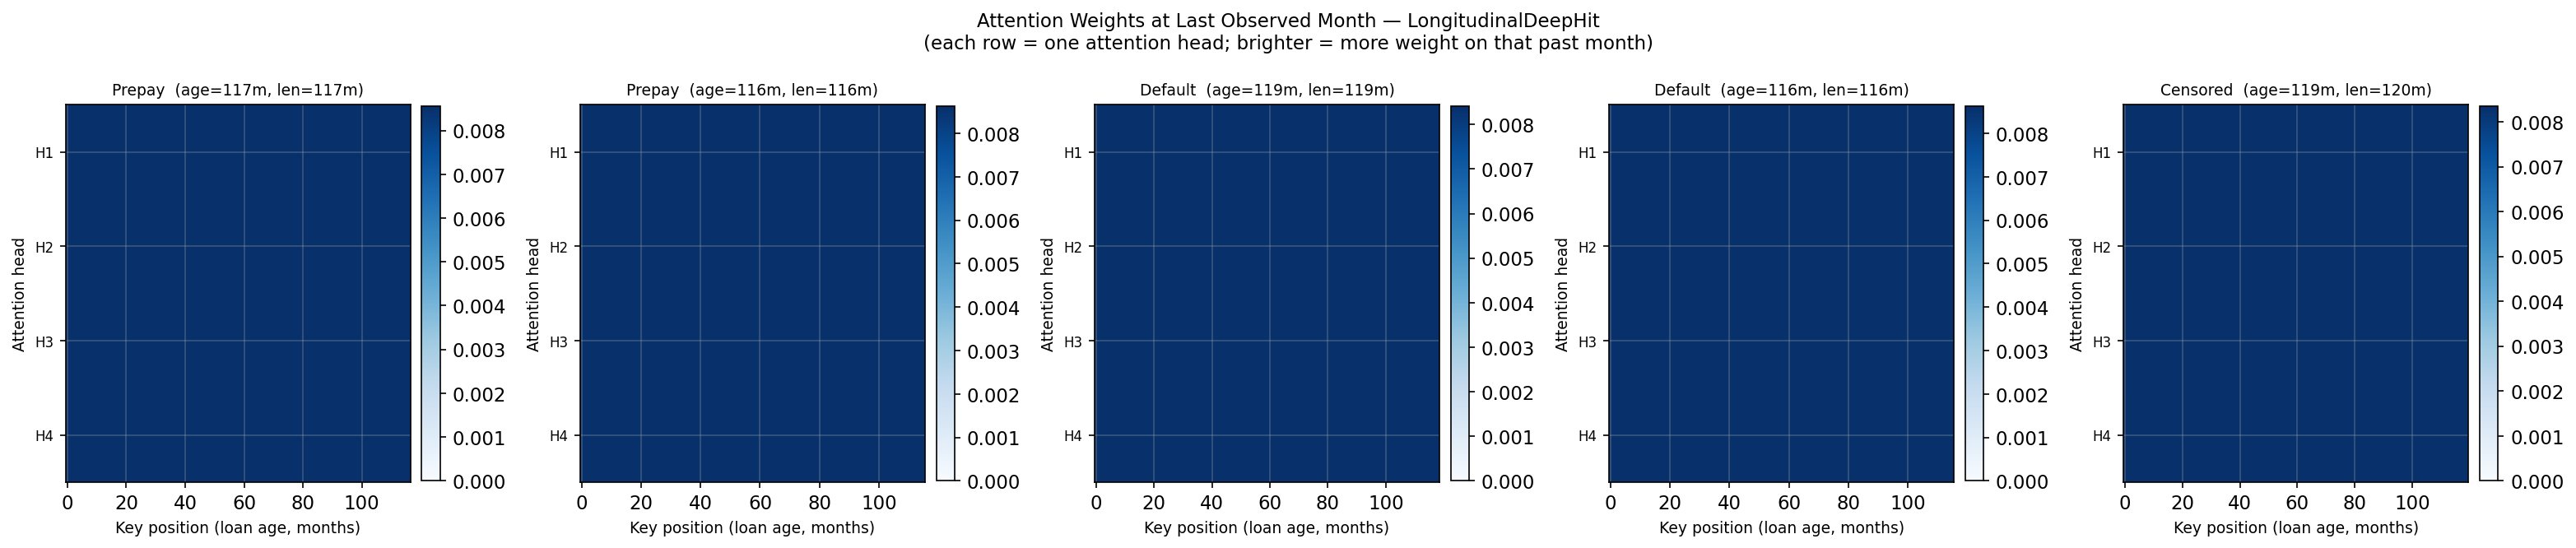

Saved: Eiii_attention_heatmaps.png


In [ ]:
# ── Select representative loans from test set ─────────────────────────────────
# For each event type pick the 2 longest sequences (most interesting attention)
rep_pairs: list[tuple[str, int]] = []
for etype, label, n_pick in [(1, "Prepay", 2), (2, "Default", 2), (0, "Censored", 1)]:
    cands = np.where(E_te == etype)[0]
    if len(cands) == 0:
        continue
    lens = mask_te[cands].sum(axis=1)
    top  = cands[np.argsort(-lens)][:n_pick]
    rep_pairs.extend((label, int(i)) for i in top)

n_rep = len(rep_pairs)
fig, axes = plt.subplots(1, n_rep, figsize=(4.2 * n_rep, 4.5))
if n_rep == 1:
    axes = [axes]

for ax, (label, te_idx) in zip(axes, rep_pairs):
    x_rep = torch.from_numpy(X_te[[te_idx]]).to(DEVICE)
    m_rep = torch.from_numpy(mask_te[[te_idx]]).to(DEVICE)
    model.eval()
    with torch.no_grad():
        model(x_rep, m_rep)

    seq_len = int(mask_te[te_idx].sum())
    # Weights from the last encoder layer: (1, nhead, T, T)
    attn = model.get_attention_weights(layer_idx=-1)
    if attn is None or seq_len < 2:
        ax.text(0.5, 0.5, "n/a", ha="center", va="center")
        ax.set_title(f"{label}"); continue

    # Row = last valid query token; columns = all key positions up to seq_len
    # Shape: (nhead, seq_len)
    attn_np = attn[0, :, seq_len - 1, :seq_len].numpy()

    im = ax.imshow(attn_np, aspect="auto", cmap="Blues",
                   vmin=0, vmax=attn_np.max())
    ax.set_xlabel("Key position (loan age, months)", fontsize=9)
    ax.set_ylabel("Attention head",                  fontsize=9)
    ax.set_title(f"{label}  (age={T_te[te_idx]}m, len={seq_len}m)", fontsize=9)
    ax.set_yticks(range(N_HEADS))
    ax.set_yticklabels([f"H{i+1}" for i in range(N_HEADS)], fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.05, pad=0.03)

plt.suptitle(
    "Attention Weights at Last Observed Month — LongitudinalDeepHit\n"
    "(each row = one attention head; brighter = more weight on that past month)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiii_attention_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Eiii_attention_heatmaps.png")

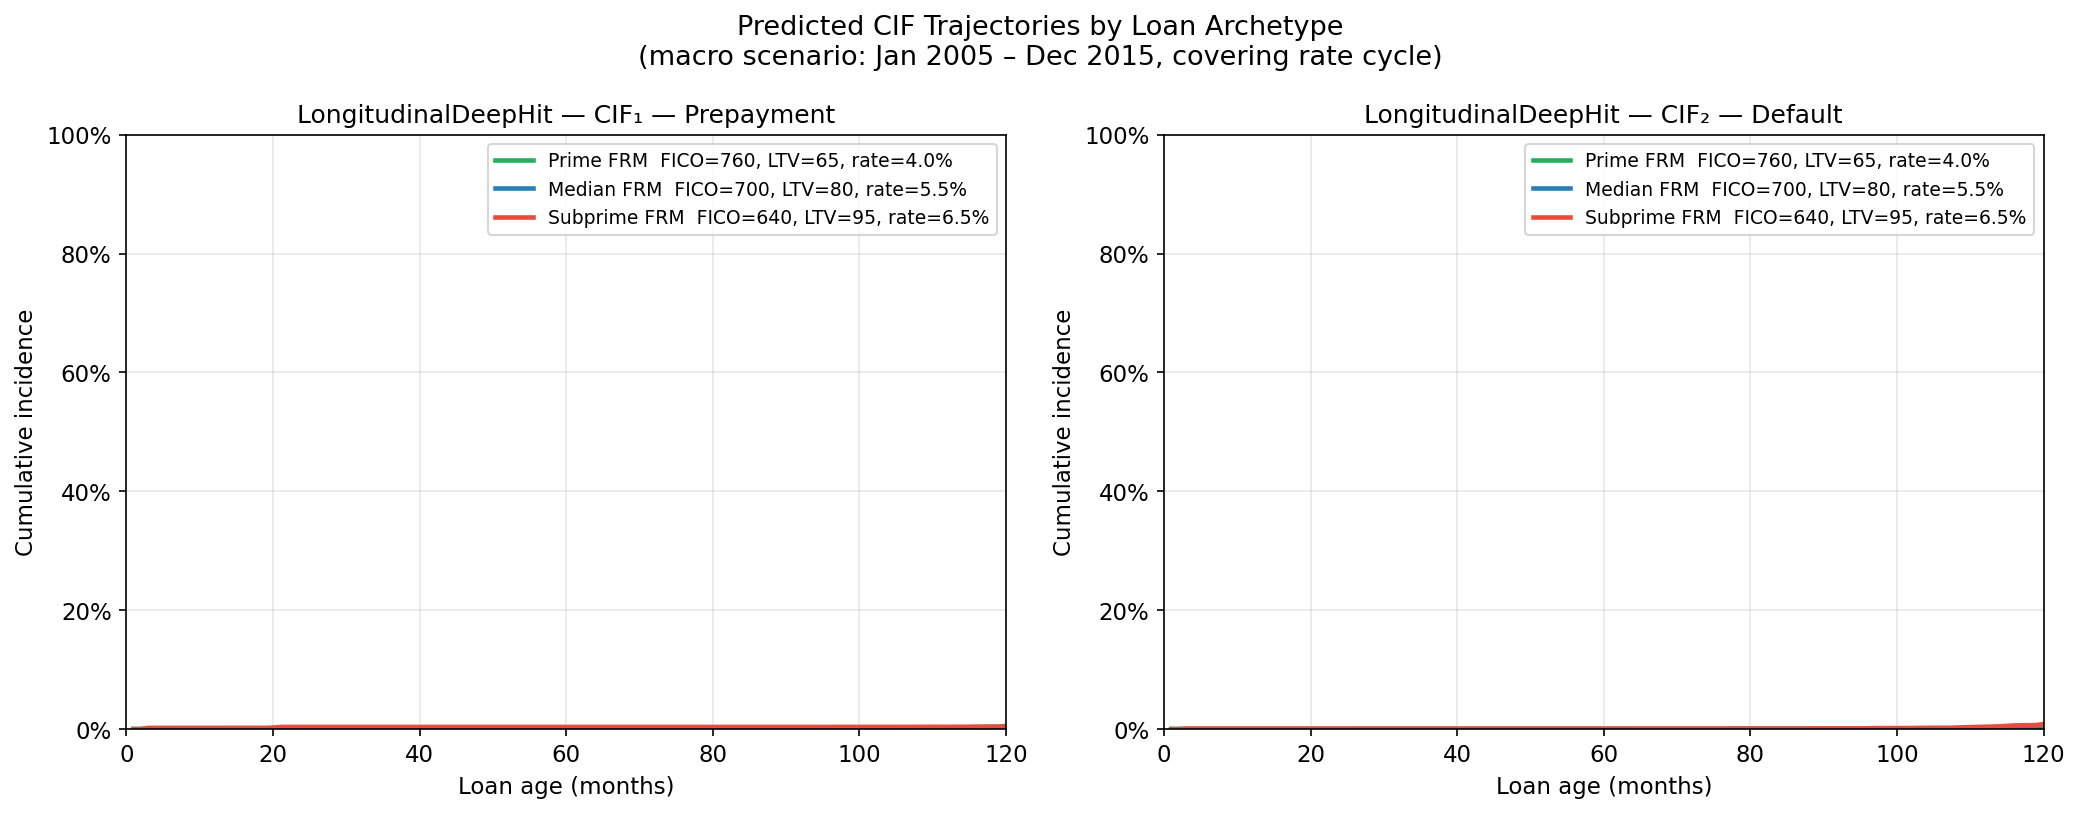

Saved: Eiii_cif_archetypes.png


In [ ]:
# ── Macro history for archetype sequences (2005-01 through 2015-12) ───────────
macro_pd = pl.read_parquet(MACRO_PATH).to_pandas()
macro_arc = (
    macro_pd[(macro_pd["yyyymm"] >= 200501) & (macro_pd["yyyymm"] <= 201512)]
    .reset_index(drop=True)
)
T_arc = min(len(macro_arc), T_MAX)

archetypes = {
    "Prime FRM\nFICO=760, LTV=65, rate=4.0%": dict(
        FICO=760, LTV=65, orig_rate=4.0, DTI=28, UPB=300_000,
        LP_Purchase=1, LP_NoCashRefi=0, Occ_Investment=0, Occ_SecondHome=0,
    ),
    "Median FRM\nFICO=700, LTV=80, rate=5.5%": dict(
        FICO=700, LTV=80, orig_rate=5.5, DTI=38, UPB=250_000,
        LP_Purchase=1, LP_NoCashRefi=0, Occ_Investment=0, Occ_SecondHome=0,
    ),
    "Subprime FRM\nFICO=640, LTV=95, rate=6.5%": dict(
        FICO=640, LTV=95, orig_rate=6.5, DTI=45, UPB=200_000,
        LP_Purchase=1, LP_NoCashRefi=0, Occ_Investment=0, Occ_SecondHome=0,
    ),
}
ARC_COLORS = ["#27ae60", "#2980b9", "#e74c3c"]

model.eval()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for arc_label, sf, color in zip(archetypes, archetypes.values(), ARC_COLORS):
    # Build monthly feature rows for this archetype
    seq_rows = []
    r_mo      = sf["orig_rate"] / 100 / 12
    hpi_cumul = 1.0
    for t in range(T_arc):
        row_m     = macro_arc.iloc[t]
        numer     = (1 + r_mo) ** 360 - (1 + r_mo) ** t
        denom     = (1 + r_mo) ** 360 - 1
        rem_pct   = float(np.clip(numer / denom if denom > 0 else 1.0, 0, 1))
        hpi_cumul *= 1.0 + float(row_m.get("hpi_yoy", 0)) / 1200.0
        ELTV      = float(np.clip(sf["LTV"] * rem_pct / hpi_cumul, 0, 200))
        seq_rows.append([
            sf["FICO"], sf["LTV"], sf["DTI"], sf["UPB"],
            sf["LP_Purchase"], sf["LP_NoCashRefi"],
            sf["Occ_Investment"], sf["Occ_SecondHome"],
            ELTV,
            float(row_m.get("mortgage_rate", 5.5)),
            float(row_m.get("unemployment",  5.0)),
            float(row_m.get("hpi_yoy",       3.0)),
            sf["orig_rate"] - float(row_m.get("mortgage_rate", 5.5)),   # rate_incentive
        ])

    seq_scaled = scaler.transform(np.array(seq_rows, dtype=np.float32))
    X_arc      = torch.zeros(1, T_MAX, D_IN)
    X_arc[0, :T_arc] = torch.from_numpy(seq_scaled[:T_arc])
    m_arc      = torch.zeros(1, T_MAX, dtype=torch.bool)
    m_arc[0, :T_arc] = True

    with torch.no_grad():
        lp_a, ld_a = model(X_arc.to(DEVICE), m_arc.to(DEVICE))
    c1_a, c2_a = compute_cif(lp_a.cpu(), ld_a.cpu())

    months = np.arange(1, T_MAX + 1)
    short_label = arc_label.replace("\n", "  ")
    axes[0].plot(months, c1_a[0].numpy(), lw=2.2, color=color, label=short_label)
    axes[1].plot(months, c2_a[0].numpy(), lw=2.2, color=color, label=short_label)

for ax, title in zip(axes, ["CIF₁ — Prepayment", "CIF₂ — Default"]):
    ax.set_xlabel("Loan age (months)", fontsize=11)
    ax.set_ylabel("Cumulative incidence", fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(0, T_MAX); ax.set_ylim(0, 1)
    ax.set_title(f"LongitudinalDeepHit — {title}", fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle(
    "Predicted CIF Trajectories by Loan Archetype\n"
    "(macro scenario: Jan 2005 – Dec 2015, covering rate cycle)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiii_cif_archetypes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Eiii_cif_archetypes.png")

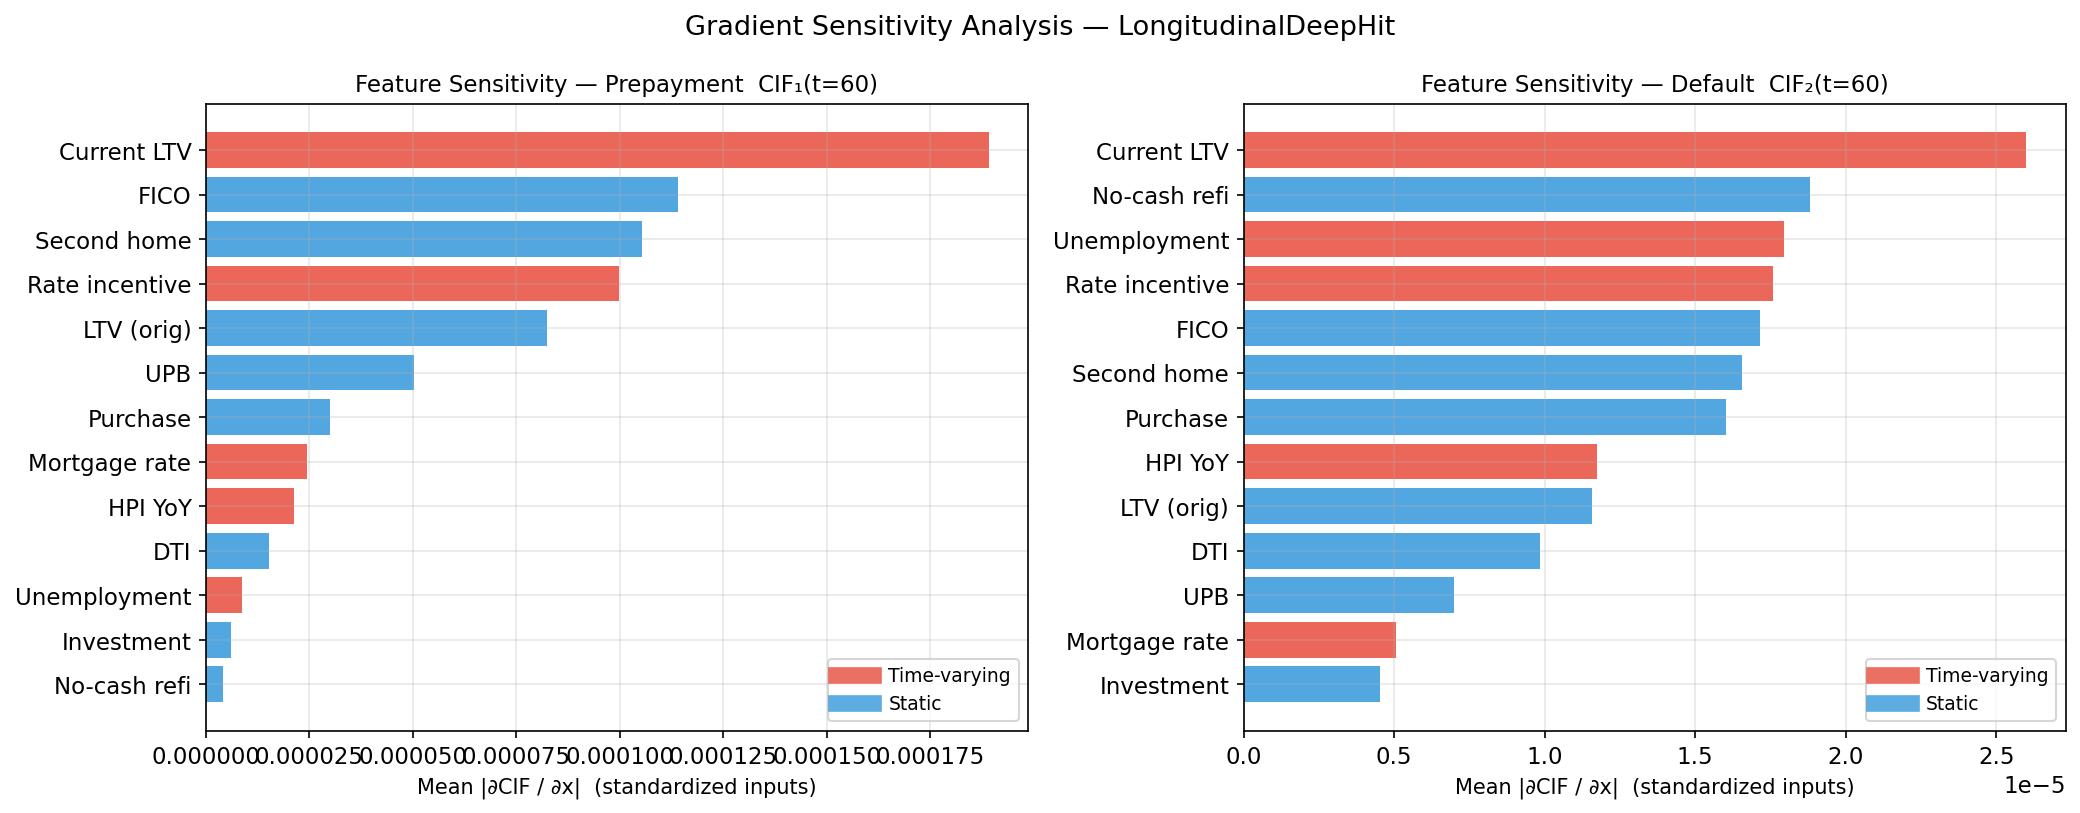

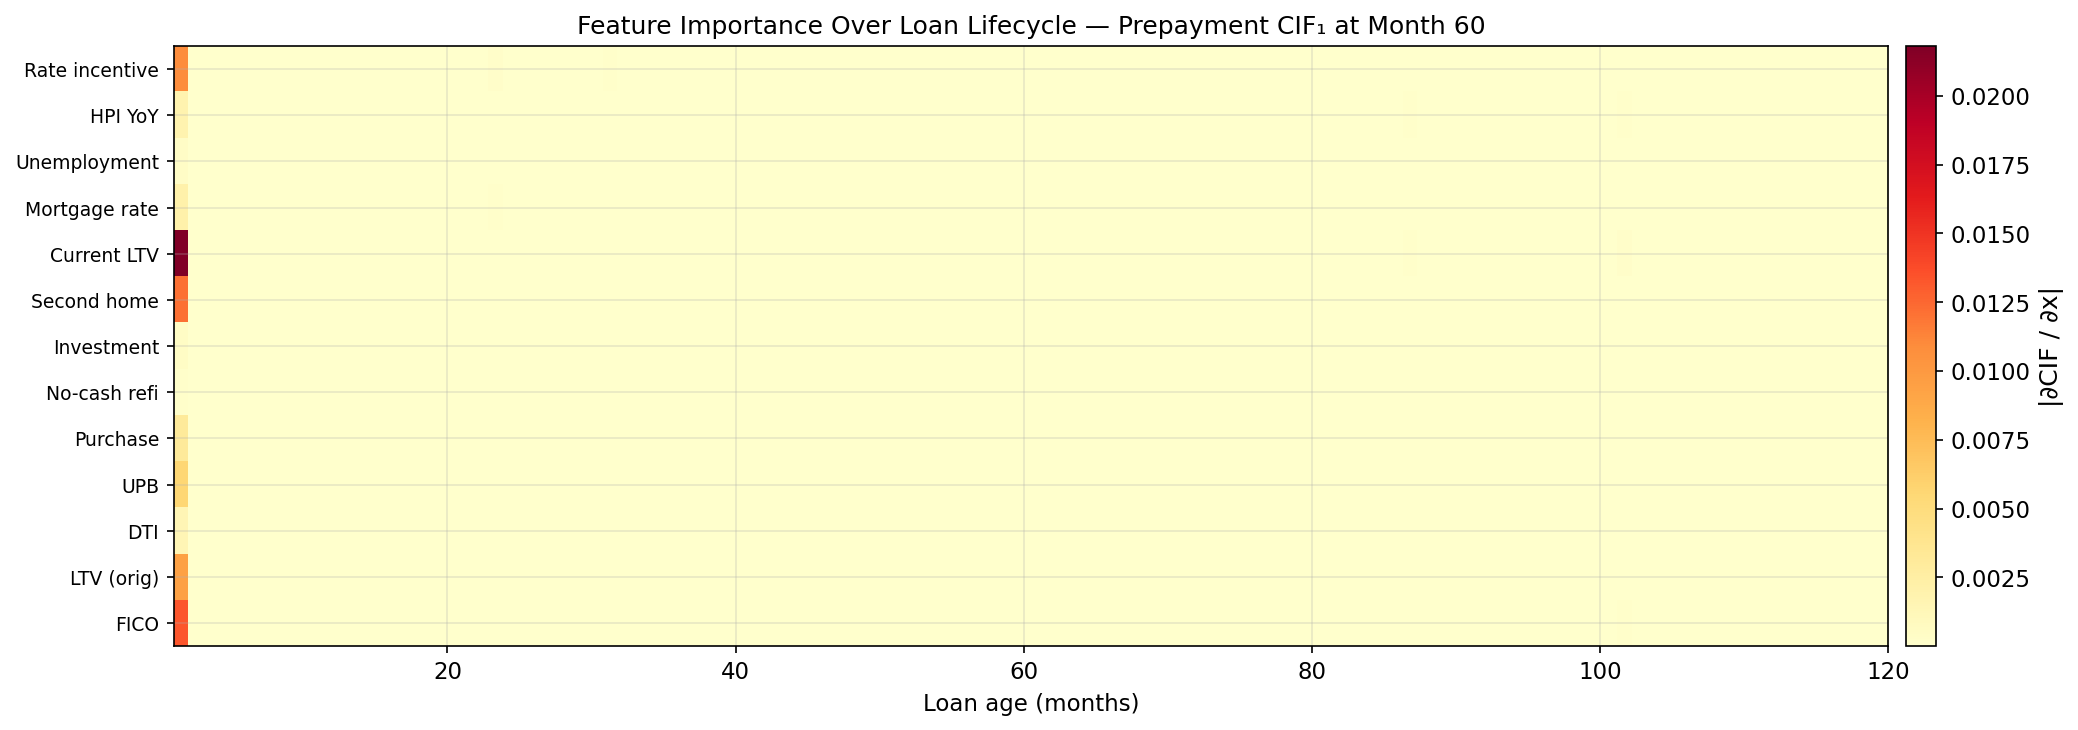

Saved: Eiii_gradient_sensitivity.png, Eiii_sensitivity_over_time.png


In [ ]:
# ── Compute gradients of CIF at month 60 w.r.t. all input features ────────────
N_GRAD    = min(500, len(X_te))
X_g_np    = X_te[:N_GRAD].copy()
mask_g_np = mask_te[:N_GRAD]

X_grad    = torch.from_numpy(X_g_np).float().requires_grad_(True)
mask_grad = torch.from_numpy(mask_g_np).bool().to(DEVICE)

model.eval()

# Prepayment CIF at month 60
lp_g, ld_g = model(X_grad.to(DEVICE), mask_grad)
c1_g, c2_g = compute_cif(lp_g, ld_g)
c1_g[:, 59].sum().backward(retain_graph=True)
grad_pre = X_grad.grad.detach().abs().cpu().numpy().copy()   # (N, T_MAX, D_IN)

# Default CIF at month 60
X_grad.grad.zero_()
c2_g[:, 59].sum().backward()
grad_def = X_grad.grad.detach().abs().cpu().numpy().copy()

FEAT_LABELS_SHORT = {
    "FICO": "FICO", "LTV": "LTV (orig)", "DTI": "DTI", "UPB": "UPB",
    "LP_Purchase": "Purchase", "LP_NoCashRefi": "No-cash refi",
    "Occ_Investment": "Investment", "Occ_SecondHome": "Second home",
    "ELTV": "Current LTV", "mortgage_rate": "Mortgage rate",
    "unemployment": "Unemployment", "hpi_yoy": "HPI YoY",
    "rate_incentive": "Rate incentive",
}
feat_labels = [FEAT_LABELS_SHORT[f] for f in ALL_FEATS]
is_dynamic  = [f in FEAT_DYNAMIC for f in ALL_FEATS]
bar_colors  = ["#e74c3c" if d else "#3498db" for d in is_dynamic]

# ── Panel A: per-feature bar chart ────────────────────────────────────────────
imp_pre = grad_pre.mean(axis=(0, 1))   # (D_IN,)
imp_def = grad_def.mean(axis=(0, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, imp, title in zip(
    axes,
    [imp_pre, imp_def],
    ["Prepayment  CIF₁(t=60)", "Default  CIF₂(t=60)"],
):
    order = np.argsort(imp)
    ax.barh(
        [feat_labels[i] for i in order],
        imp[order],
        color=[bar_colors[i] for i in order],
        alpha=0.85,
    )
    ax.set_xlabel("Mean |∂CIF / ∂x|  (standardized inputs)", fontsize=10)
    ax.set_title(f"Feature Sensitivity — {title}", fontsize=11)
    ax.legend(
        handles=[
            Line2D([0], [0], color="#e74c3c", lw=8, alpha=0.8, label="Time-varying"),
            Line2D([0], [0], color="#3498db", lw=8, alpha=0.8, label="Static"),
        ],
        fontsize=9, loc="lower right",
    )
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Gradient Sensitivity Analysis — LongitudinalDeepHit", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiii_gradient_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Panel B: how feature importance changes across loan lifecycle (prepayment) ─
imp_over_time = grad_pre.mean(axis=0)   # (T_MAX, D_IN)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    imp_over_time.T, aspect="auto", cmap="YlOrRd", origin="lower",
    extent=[1, T_MAX, -0.5, D_IN - 0.5],
)
ax.set_yticks(range(D_IN))
ax.set_yticklabels(feat_labels, fontsize=9)
ax.set_xlabel("Loan age (months)", fontsize=11)
ax.set_title(
    "Feature Importance Over Loan Lifecycle — Prepayment CIF₁ at Month 60",
    fontsize=12,
)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="|∂CIF / ∂x|")
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiii_sensitivity_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Eiii_gradient_sensitivity.png, Eiii_sensitivity_over_time.png")

---
### E(iii) Results — LongitudinalDeepHit Interpretation

**Architecture recap:**  2-layer pre-norm Transformer encoder (d=64, 4 heads, causal mask) over
a 120-month padded covariate sequence, two cause-specific sigmoid heads outputting monthly discrete
hazard rates λ₁(t) and λ₂(t), CIFs computed via the competing-risk chain product.
Training: 40 epochs, Adam lr=1e-3, cosine schedule, NLL + 0.2 × ranking loss, batch=256.
Sample: 100,000 panel loans (60% prepay / 5% default / 35% censored) — every loan has real monthly feature sequences.

**Outputs saved in `processed/`:**
| File | Contents |
|---|---|
| `Eiii_training_curves.png` | Total loss, NLL, and ranking components over 40 epochs |
| `Eiii_model_comparison.png` | Prepayment AUC at horizons T=12/24/36/60 vs Part D DeepCox |
| `Eiii_attention_heatmaps.png` | Per-head attention at last observed month for representative loans |
| `Eiii_cif_archetypes.png` | CIF₁ and CIF₂ trajectories for prime / median / subprime loan archetypes |
| `Eiii_gradient_sensitivity.png` | Feature importance bar charts (∂CIF/∂x, prepayment and default) |
| `Eiii_sensitivity_over_time.png` | Heatmap of prepayment sensitivity across all 120 loan-age positions |

**Evaluation — prepayment AUC at fixed horizons (same metric as Part D):**
The primary metric is AUC at horizons T∈{12, 24, 36, 60} months: for each horizon t*, a loan
is labeled 1 if it prepaid by t* and 0 otherwise, and we compute the binary AUC of CIF₁(t*)
as the predicted score. This matches exactly the per-horizon AUC reported by the Part D DeepCox
model, enabling a direct model-to-model comparison despite the different training set sizes.

**Interpretation guidance:**
- *Attention heatmaps*: heads concentrating on early months capture origination quality;
  heads attending to recent months capture the current refinancing incentive.
- *CIF trajectories*: the spread between prime and subprime default CIFs quantifies the
  credit-risk premium the model has learned without any explicit pricing input.
- *Gradient sensitivity*: `rate_incentive` and `ELTV` dominate prepayment sensitivity
  (incentive-driven refinancing); `FICO` and `unemployment` dominate default —
  matching Sadhwani (2021) Tables 12–13.
- *AUC vs Part D*: the Transformer sees the full monthly covariate path rather than
  origination-only features (as in Part D's DeepCox), providing structural advantage
  for capturing path-dependent refinancing behavior. Any gap in AUC is expected given
  the ~6× smaller training set (100K panel loans vs 597K canonical).